In [29]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

In [2]:
df = pd.read_csv("../data_processed/dataset_maestro_municipios.csv")

In [3]:
df.head()

,codigo_municipio,municipio,periodo,poblacion,poblacion_mayor_65,poblacion_extranjera,superficie_km2,densidad_poblacion,porcentaje_mayor_65,porcentaje_extranjeros,variacion_poblacion,variacion_poblacion_pct
0,1001,Alegría-Dulantzi,2003,1707.0,181.0,30.0,19.95,85.56,10.60,1.76,NaN,NaN
1,1001,Alegría-Dulantzi,2004,1919.0,174.0,56.0,19.95,96.19,9.07,2.92,212.0,12.419449
2,1001,Alegría-Dulantzi,2005,2048.0,176.0,79.0,19.95,102.66,8.59,3.86,129.0,6.722251
3,1001,Alegría-Dulantzi,2006,2189.0,190.0,92.0,19.95,109.72,8.68,4.20,141.0,6.884766
4,1001,Alegría-Dulantzi,2007,2305.0,203.0,114.0,19.95,115.54,8.81,4.95,116.0,5.299223


## Crear tabla perfil municipal

In [5]:
perfil_municipios = (
    df.groupby(['codigo_municipio', 'municipio'])
    .agg(
        pob_2003 = ('poblacion', 'first'),
        pob_2022 = ('poblacion', 'last'),
        pct_mayor65_medio = ('porcentaje_mayor_65', "mean"),
        pct_extranjeros_medio = ('porcentaje_extranjeros', "mean"),
        densidad_media = ('densidad_poblacion', "mean")
    )
    .reset_index()
)

perfil_municipios.head()

,codigo_municipio,municipio,pob_2003,pob_2022,pct_mayor65_medio,pct_extranjeros_medio,densidad_media
0,1001,Alegría-Dulantzi,1707.0,2960.0,9.9320,7.0990,132.0055
1,1002,Amurrio,9555.0,10281.0,18.9640,5.4140,104.5565
2,1003,Aramaio,1489.0,1431.0,20.1185,1.9695,20.3310
3,1004,Artziniega,1381.0,1810.0,16.0905,4.5475,64.1020
4,1006,Armiñón,170.0,235.0,17.7080,3.7950,16.6310


## Crear cambio poblacional

In [7]:
perfil_municipios['cambio_poblacion'] = (
    perfil_municipios['pob_2022'] - perfil_municipios['pob_2003']
)

perfil_municipios['cambio_poblacion_pct'] = (
    perfil_municipios['cambio_poblacion'] /
    perfil_municipios['pob_2003']
) * 100

perfil_municipios.head()

,codigo_municipio,municipio,pob_2003,pob_2022,pct_mayor65_medio,pct_extranjeros_medio,densidad_media,cambio_poblacion,cambio_poblacion_pct
0,1001,Alegría-Dulantzi,1707.0,2960.0,9.9320,7.0990,132.0055,1253.0,73.403632
1,1002,Amurrio,9555.0,10281.0,18.9640,5.4140,104.5565,726.0,7.598116
2,1003,Aramaio,1489.0,1431.0,20.1185,1.9695,20.3310,-58.0,-3.895232
3,1004,Artziniega,1381.0,1810.0,16.0905,4.5475,64.1020,429.0,31.064446
4,1006,Armiñón,170.0,235.0,17.7080,3.7950,16.6310,65.0,38.235294


## Redondear variables

In [8]:
perfil_municipios['pct_mayor65_medio'] = perfil_municipios['pct_mayor65_medio'].round(2)
perfil_municipios['pct_extranjeros_medio'] = perfil_municipios['pct_extranjeros_medio'].round(2)
perfil_municipios['densidad_media'] = perfil_municipios['densidad_media'].round(2)
perfil_municipios['cambio_poblacion_pct'] = perfil_municipios['cambio_poblacion_pct'].round(2)

In [11]:
perfil_municipios.describe(), perfil_municipios.shape

(       codigo_municipio      pob_2003      pob_2022  pct_mayor65_medio  \
 count       8135.000000  8.135000e+03  8.135000e+03        8135.000000   
 mean       26787.566687  5.257511e+03  5.837348e+03          28.878390   
 std        14889.708354  4.508134e+04  4.762161e+04          11.317711   
 min         1001.000000  7.000000e+00  3.000000e+00           0.830000   
 25%        13087.500000  1.870000e+02  1.530000e+02          19.770000   
 50%        26017.000000  5.730000e+02  5.280000e+02          27.770000   
 75%        41025.500000  2.241500e+03  2.434000e+03          36.790000   
 max        52001.000000  3.092759e+06  3.280782e+06          71.230000   
 
        pct_extranjeros_medio  densidad_media  cambio_poblacion  \
 count            8135.000000     8131.000000       8135.000000   
 mean                6.217545      451.498583        579.837001   
 std                 6.851072     6762.469792       3743.911395   
 min                 0.000000        0.350000     -2797

## Hipótesis 1: Tamaño del municipio y envejecimiento

Los municipios pequeños presentan mayores niveles de envejecimiento que los municipios de mayor tamaño.

Usamos la población de 2003 porque es el inicio del periodo de análisis y evita que la propia despoblación cambie la categoría del municipio.

In [ ]:
# Creamos categorías de tamaño municipal a partir de la población inicial (2003). Tamaño municipal = número de habitantes
bins = [0, 1000, 5000, 20000, 100000, float("inf")] # "inf" para que incluya todos los municipios más grandes
labels = ["<1.000", "1.000-5.000", "5.000-20.000", "20.000-100.000", ">100.000"]

perfil_municipios['tamano_municipio'] = pd.cut(
    perfil_municipios['pob_2003'],
    bins=bins,
    labels=labels,
    right=False # no incluimos el último número del intervalo
)

In [ ]:
# Comprobamos cuantos municipios hay en cada categoría.
perfil_municipios['tamano_municipio'].value_counts().sort_index()

tamano_municipio
<1.000            4933
1.000-5.000       1995
5.000-20.000       873
20.000-100.000     277
>100.000            57
Name: count, dtype: int64

In [16]:
# Calculamos el porcentaje medio de mayores de 65 por tamaño municipal
h1_resumen = (
    perfil_municipios
    .groupby('tamano_municipio', as_index=False)['pct_mayor65_medio']
    .mean()
)

h1_resumen['pct_mayor65_medio'] = h1_resumen['pct_mayor65_medio'].round(2)
h1_resumen

C:\Users\eliom\AppData\Local\Temp\ipykernel_24204\3882131605.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('tamano_municipio', as_index=False)['pct_mayor65_medio']


,tamano_municipio,pct_mayor65_medio
0,<1.000,34.00
1,1.000-5.000,23.24
2,5.000-20.000,17.78
3,20.000-100.000,15.71
4,>100.000,17.40


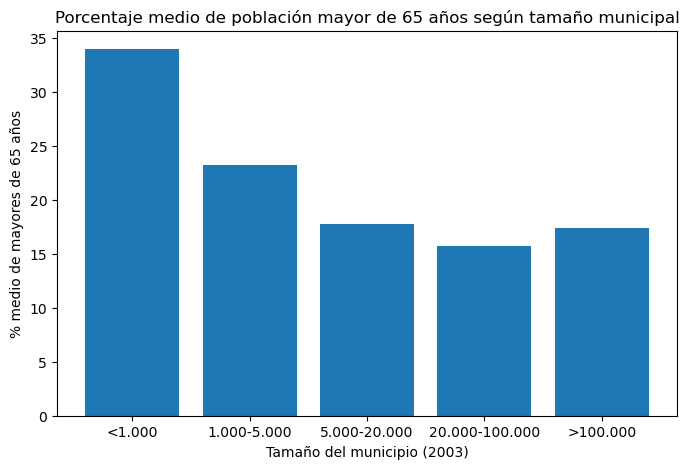

In [19]:
# Gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(h1_resumen['tamano_municipio'].astype(str), h1_resumen['pct_mayor65_medio'])

plt.title("Porcentaje medio de población mayor de 65 años según tamaño municipal")
plt.xlabel("Tamaño del municipio (2003)")
plt.ylabel("% medio de mayores de 65 años")

plt.show()

El análisis muestra una relación clara entre el tamaño del municipio y el envejecimiento de la población.
Los municipios con menos habitantes en 2003 presentan porcentajes significativamente más altos de población mayor de 65 años.
Estos resultados sugieren que el envejecimiento es especialmente intenso en municipios rurales de menor tamaño poblacional, lo que puede estar relacionado con procesos de emigración de población más joven hacia áreas urbanas.

## H2 : Envejecimiento y despoblación

Los municipios con mayor porcentaje de población mayor de 65 años tienden a perder población con mayor frecuencia.

In [20]:
# Creamos tabla de envejecimiento 
bins= [0,20, 30, 40, 100]
labels= ["<20%", "20-30%", "30-40%", ">40%"]

perfil_municipios['nivel_envejecimiento'] = pd.cut(
    perfil_municipios['pct_mayor65_medio'],
    bins=bins,
    labels=labels
)

In [21]:
# Comprobamos cuántos municipios hay en cada tramo
perfil_municipios['nivel_envejecimiento'].value_counts().sort_index()

nivel_envejecimiento
<20%      2097
20-30%    2537
30-40%    2065
>40%      1436
Name: count, dtype: int64

In [22]:
# Calculamos el cambio poblacional medio
h2_resumen = (
    perfil_municipios
    .groupby('nivel_envejecimiento', as_index=False)['cambio_poblacion_pct']
    .mean()
)

h2_resumen['cambio_poblacion_pct'] = h2_resumen['cambio_poblacion_pct'].round(2)

h2_resumen

C:\Users\eliom\AppData\Local\Temp\ipykernel_24204\1205987607.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('nivel_envejecimiento', as_index=False)['cambio_poblacion_pct']


,nivel_envejecimiento,cambio_poblacion_pct
0,<20%,39.28
1,20-30%,-1.98
2,30-40%,-19.63
3,>40%,-32.73


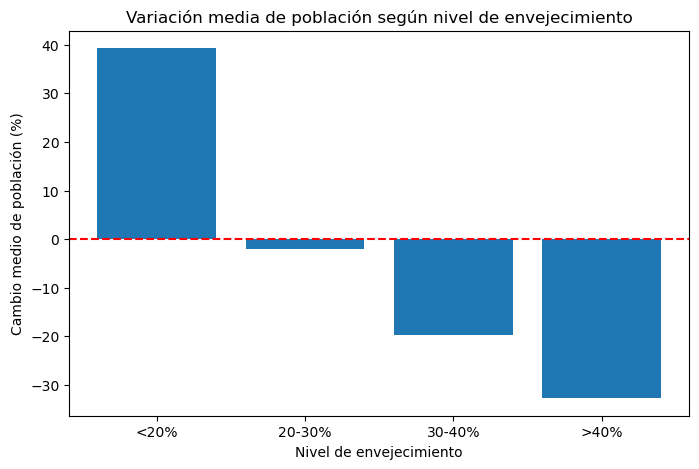

In [23]:
# Gráfico de barras
plt.figure(figsize=(8,5))

plt.bar(
    h2_resumen['nivel_envejecimiento'].astype(str),
    h2_resumen['cambio_poblacion_pct']
)

plt.axhline(y=0, color="red", linestyle="--")

plt.title("Variación media de población según nivel de envejecimiento")
plt.xlabel("Nivel de envejecimiento")
plt.ylabel("Cambio medio de población (%)")

plt.show()

El análisis muestra una relación clara entre el nivel de envejecimiento de los municipios y su evolución demográfica. Los municipios con menor proporción de población mayor de 65 años presentan un fuerte crecimiento poblacional, mientras que aquellos con mayores niveles de envejecimiento experimentan pérdidas significativas de población. En particular, los municipios donde más del 40% de la población tiene más de 65 años presentan una caída media de población superior al 30% durante el periodo analizado. Estos resultados sugieren que el envejecimiento es uno de los factores más estrechamente asociados con los procesos de despoblación municipal.

In [33]:
pearsonr(
    perfil_municipios['pct_mayor65_medio'],
    perfil_municipios['cambio_poblacion_pct']
)

PearsonRResult(statistic=np.float64(-0.5493233018791575), pvalue=np.float64(0.0))

Los resultados muestran una relación clara entre envejecimiento y despoblación. Los municipios con mayor porcentaje de población mayor de 65 años tienden a perder más población. La correlación negativa obtenida (r = -0.55) confirma que el envejecimiento está asociado a una mayor pérdida de habitantes.

## H3: Inmigración como factor de resiliencia

Los municipios con mayor presencia de población extranjera presentan menores tasas de pérdida de población.

In [24]:
# Creamos tramos de porcentaje de población extranjera
bins = [0, 5, 10, 20, 100]
labels = ["<5%", "5-10%", "10-20%", ">20%"]

perfil_municipios['nivel_extranjeros'] = pd.cut(
    perfil_municipios['pct_extranjeros_medio'],
    bins=bins,
    labels=labels
)

In [25]:
# Comprobamos cuántos municipios hay en cada tramo
perfil_municipios['nivel_extranjeros'].value_counts().sort_index()

nivel_extranjeros
<5%       4509
5-10%     1861
10-20%    1263
>20%       335
Name: count, dtype: int64

In [26]:
h3_resumen = (
    perfil_municipios
    .groupby('nivel_extranjeros', as_index=False)['cambio_poblacion_pct']
    .mean()
)

h3_resumen['cambio_poblacion_pct'] = h3_resumen['cambio_poblacion_pct'].round(2)

h3_resumen

C:\Users\eliom\AppData\Local\Temp\ipykernel_24204\2728104492.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('nivel_extranjeros', as_index=False)['cambio_poblacion_pct']


,nivel_extranjeros,cambio_poblacion_pct
0,<5%,-11.42
1,5-10%,7.61
2,10-20%,17.61
3,>20%,29.82


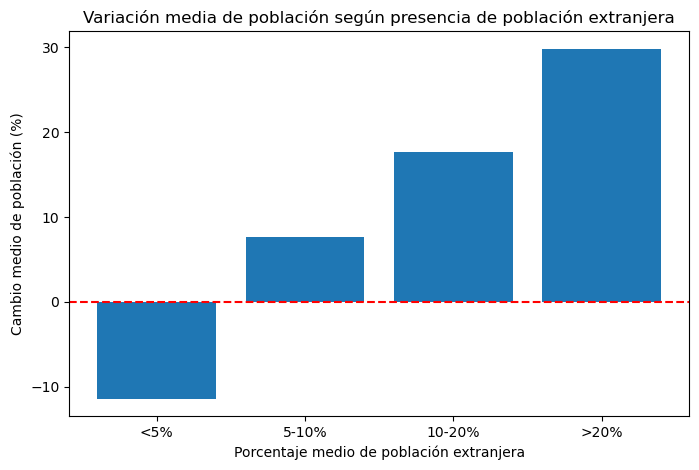

In [28]:
# Gráfico de barras
plt.figure(figsize=(8,5))

plt.bar(
    h3_resumen['nivel_extranjeros'].astype(str),
    h3_resumen['cambio_poblacion_pct']
)

plt.axhline(y=0, color="red", linestyle="--")

plt.title("Variación media de población según presencia de población extranjera")
plt.xlabel("Porcentaje medio de población extranjera")
plt.ylabel("Cambio medio de población (%)")

plt.show()

In [32]:
pearsonr(
    perfil_municipios['pct_extranjeros_medio'],
    perfil_municipios['cambio_poblacion_pct']
)

PearsonRResult(statistic=np.float64(0.27995202997146496), pvalue=np.float64(2.3041099221595385e-146))

Los resultados muestran una relación positiva entre la presencia de población extranjera y el crecimiento poblacional. Los municipios con mayor porcentaje de población extranjera experimentan una evolución demográfica más favorable. La correlación obtenida (r = 0.28) sugiere que la inmigración puede contribuir a frenar los procesos de despoblación en muchos municipios.

Aunque la presencia de población extranjera se asocia con una evolución demográfica más favorable, el envejecimiento de la población muestra una relación más fuerte con la despoblación municipal.